# Analysis: 20250708

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from cdk.analysis.cytosol import platereader as pr

# Filter warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [7]:
data_file = "./20250708-cytation3-pure-timecourse-gfp-onepot-debug-01-pure-test-biotek-cdk.txt"
platemap_file = "./platemap.tsv"

data, platemap = pr.load_platereader_data(data_file, platemap_file)
data = data[data["Row"].isin(["B","D"])]

# Basic Analysis

## Curves
Curves of RFU over time, by named sample.

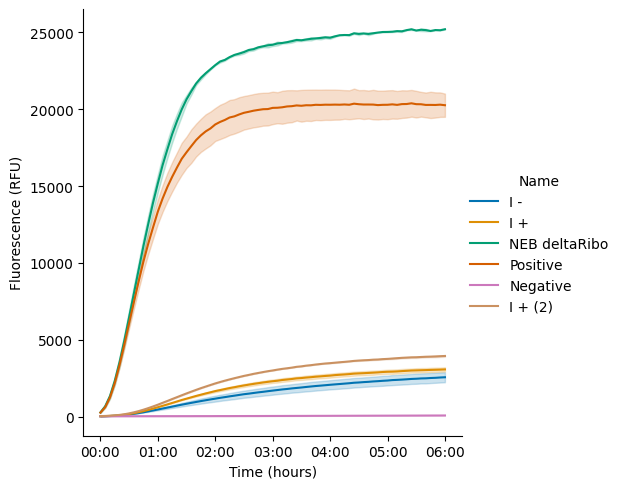

In [12]:
#| label: fig:timeseries-exp1

pr.plot_curves(data, palette="colorblind");
plt.savefig("20250708-timeseries-exp1")

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

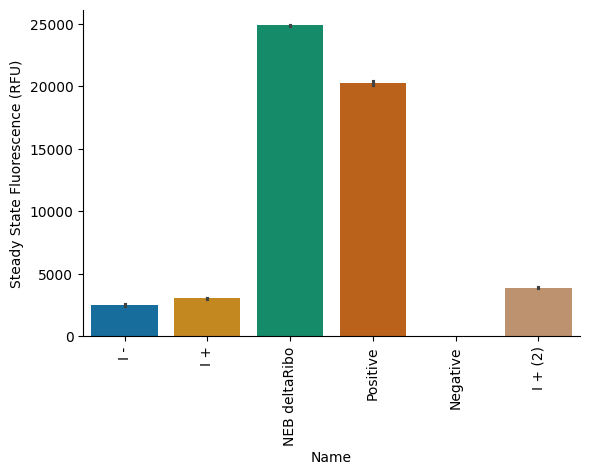

In [11]:
#| label: fig:endpoint-exp1

pr.plot_steadystate(data, palette="colorblind");
plt.savefig("20250708-endpoint-exp1")

## Kinetics
These functions calculate key kinetic parameters of the time series.

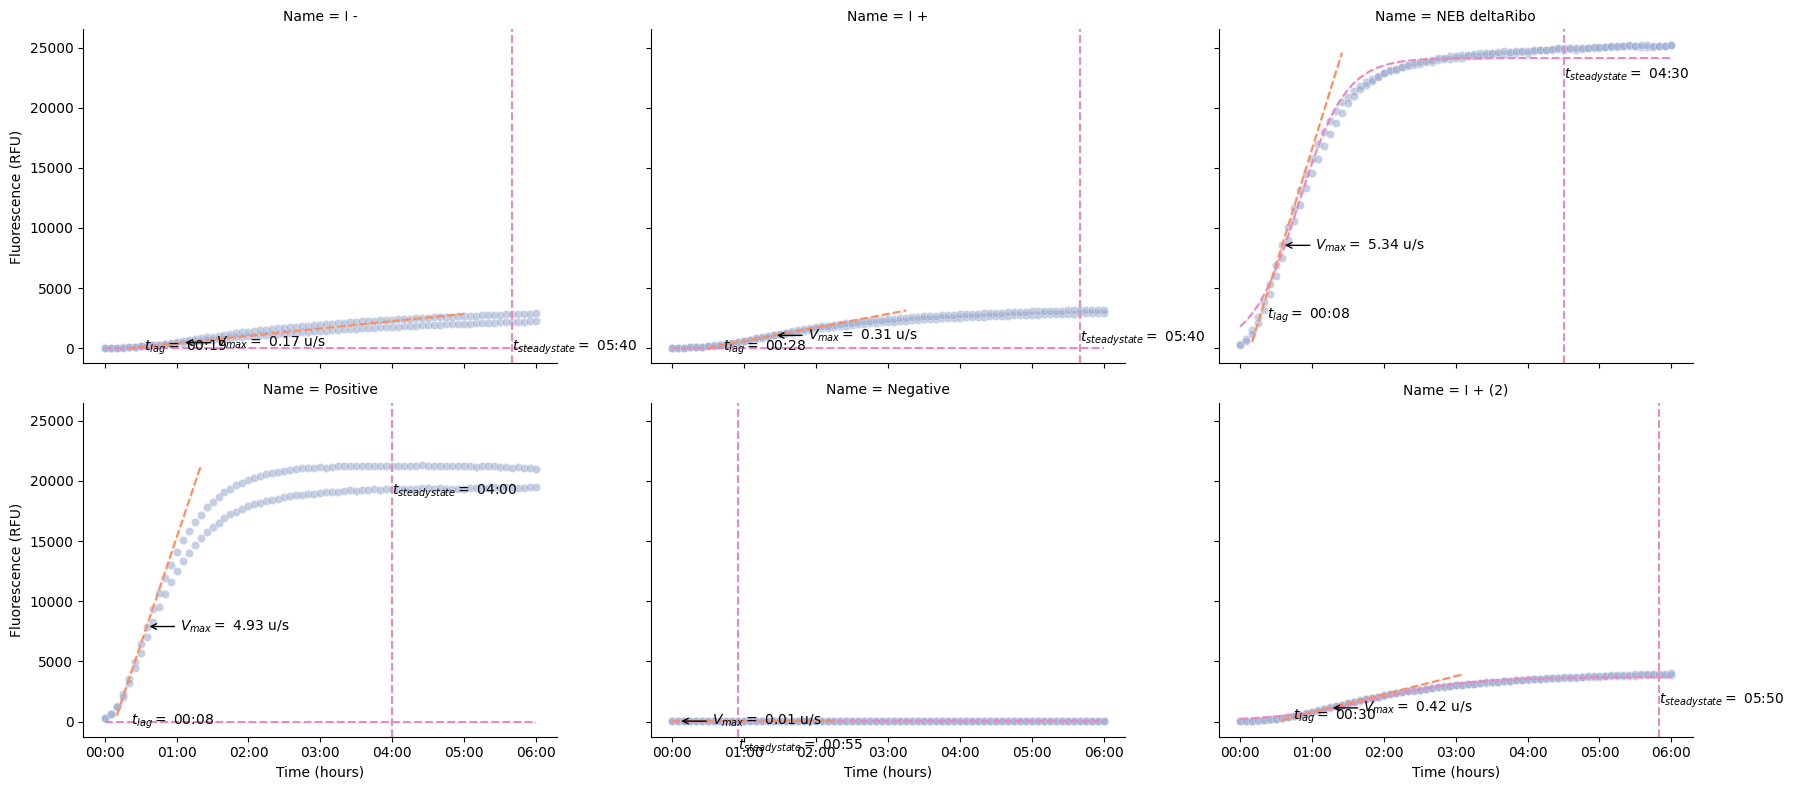

In [10]:
pr.plot_kinetics(data)

We can also calculate the kinetics and display the parameters as a table.

In [11]:
pr.kinetic_analysis(data)

Velocity             \
                                        Time  Data  Max   
Well Name          Read                                   
B2   I -           GFP-F-G35 0 days 01:05:00   467 0.17   
B4   I +           GFP-F-G35 0 days 01:25:00  1070 0.31   
B6   NEB deltaRibo GFP-F-G35 0 days 00:35:00  8556 5.34   
B8   Positive      GFP-F-G35 0 days 00:35:00  7900 4.93   
B10  Negative      GFP-F-G35 0 days 00:05:00    33 0.01   
B12  I + (2)       GFP-F-G35 0 days 01:15:00  1133 0.42   
D3   I -           GFP-F-G35 0 days 01:05:00   602 0.26   
D4   I +           GFP-F-G35 0 days 01:15:00   912 0.33   
D6   NEB deltaRibo GFP-F-G35 0 days 00:40:00  9021 5.14   
D8   Positive      GFP-F-G35 0 days 00:30:00  5735 4.36   
D10  Negative      GFP-F-G35 0 days 00:05:00    36 0.01   
D12  I + (2)       GFP-F-G35 0 days 01:15:00  1171 0.42   

                                                   Lag          \
                                                  Time    Data   
Well Name          Read                                          
B2   I -           GFP-F-G35 0 days 00:19:12.941176471    0.00   
B4   I +           GFP-F-G35 0 days 00:28:05.106382979    0.00   
B6   NEB deltaRibo GFP-F-G35 0 days 00:08:18.752339364 2669.52   
B8   Positive      GFP-F-G35 0 days 00:08:17.565922921    0.00   
B10  Negative      GFP-F-G35         -1 days +22:42:30   12.47   
B12  I + (2)       GFP-F-G35 0 days 00:30:02.380952381  424.93   
D3   I -           GFP-F-G35 0 days 00:25:54.545454545  311.15   
D4   I +           GFP-F-G35           0 days 00:29:24  347.76   
D6   NEB deltaRibo GFP-F-G35 0 days 00:10:43.802725503 2710.19   
D8   Positive      GFP-F-G35 0 days 00:08:04.633027523    0.00   
D10  Negative      GFP-F-G35         -1 days +22:35:00    0.00   
D12  I + (2)       GFP-F-G35 0 days 00:28:31.904761905  446.01   

                                Steady State             Fit                
                                        Time   Data        L    k       x0  
Well Name          Read                                                     
B2   I -           GFP-F-G35 0 days 05:40:00   2169     0.00 0.00     0.00  
B4   I +           GFP-F-G35 0 days 05:40:00   2898     0.00 0.00     0.00  
B6   NEB deltaRibo GFP-F-G35 0 days 04:30:00  24812 24130.36 0.00  2937.00  
B8   Positive      GFP-F-G35 0 days 04:00:00  21275     0.00 0.00     0.00  
B10  Negative      GFP-F-G35 0 days 00:55:00     36    37.89 0.00 -3222.04  
B12  I + (2)       GFP-F-G35 0 days 05:50:00   3866  3705.53 0.00  6714.75  
D3   I -           GFP-F-G35 0 days 05:50:00   2856  2739.64 0.00  7721.68  
D4   I +           GFP-F-G35 0 days 05:45:00   3185  3033.19 0.00  6847.01  
D6   NEB deltaRibo GFP-F-G35 0 days 04:45:00  24975 24408.85 0.00  3229.30  
D8   Positive      GFP-F-G35 0 days 04:00:00  19300     0.00 0.00     0.00  
D10  Negative      GFP-F-G35 0 days 00:30:00     37    37.35 0.00  -700.59  
D12  I + (2)       GFP-F-G35 0 days 05:45:00   3952  3778.58 0.00  6818.50